# Predicting NASDAQ Stock Direction with GRU
## Neural Networks & Deep Learning — Final Project 2025
### Optiver Trading at the Close · Binary Classification

**Task:** Predict whether a stock's Weighted Average Price (WAP) will go **up or down** during the NASDAQ Closing Cross auction (last 10 minutes of trading).  
**Model:** Gated Recurrent Unit (GRU) trained on order book + auction sequence data.


## 1. Imports & Configuration

In [37]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, log_loss
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Global style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8FAFC",
    "axes.edgecolor":    "#CBD5E1",
    "axes.labelcolor":   "#334155",
    "xtick.color":       "#334155",
    "ytick.color":       "#334155",
    "text.color":        "#1E293B",
    "grid.color":        "#E2E8F0",
    "grid.linewidth":    0.6,
    "legend.facecolor":  "white",
    "legend.edgecolor":  "#CBD5E1",
    "font.family":       "DejaVu Sans",
})
TEAL   = "#0D9488"
PURPLE = "#6D28D9"
AMBER  = "#D97706"
RED    = "#DC2626"

# ── Hyperparameters ───────────────────────────────────────────────────────
INTERVAL_SECONDS = 10   # bucket width in seconds
EPOCHS           = 10
BATCH_SIZE       = 64
HIDDEN_SIZE      = 64
NUM_LAYERS       = 2
DROPOUT          = 0.3
LR               = 0.001
WEIGHT_DECAY     = 0.01
SEED             = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Interval: {INTERVAL_SECONDS}s  |  Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}")


Device: cpu
Interval: 10s  |  Epochs: 10  |  Batch: 64


## 2. Load & Inspect Data

In [38]:
train = pd.read_csv("train.csv")
train = train.dropna(subset=["target"])

print(f"Shape: {train.shape}")
print(f"Stocks:         {train['stock_id'].nunique()}")
print(f"Trading dates:  {train['date_id'].nunique()}")
print(f"Missing values:\n{train.isnull().sum()[train.isnull().sum() > 0]}")
train.head()


Shape: (5237892, 17)
Stocks:         200
Trading dates:  481
Missing values:
imbalance_size         132
reference_price        132
matched_size           132
far_price          2894254
near_price         2857092
bid_price              132
ask_price              132
wap                    132
dtype: int64


,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id,row_id
0,0,0,0,3180602.69,1,0.999812,13380276.64,NaN,NaN,0.999812,60651.50,1.000026,8493.03,1.0,-3.029704,0,0_0_0
1,1,0,0,166603.91,-1,0.999896,1642214.25,NaN,NaN,0.999896,3233.04,1.000660,20605.09,1.0,-5.519986,0,0_0_1
2,2,0,0,302879.87,-1,0.999561,1819368.03,NaN,NaN,0.999403,37956.00,1.000298,18995.00,1.0,-8.389950,0,0_0_2
3,3,0,0,11917682.27,-1,1.000171,18389745.62,NaN,NaN,0.999999,2324.90,1.000214,479032.40,1.0,-4.010200,0,0_0_3
4,4,0,0,447549.96,-1,0.999532,17860614.95,NaN,NaN,0.999394,16485.54,1.000016,434.10,1.0,-7.349849,0,0_0_4


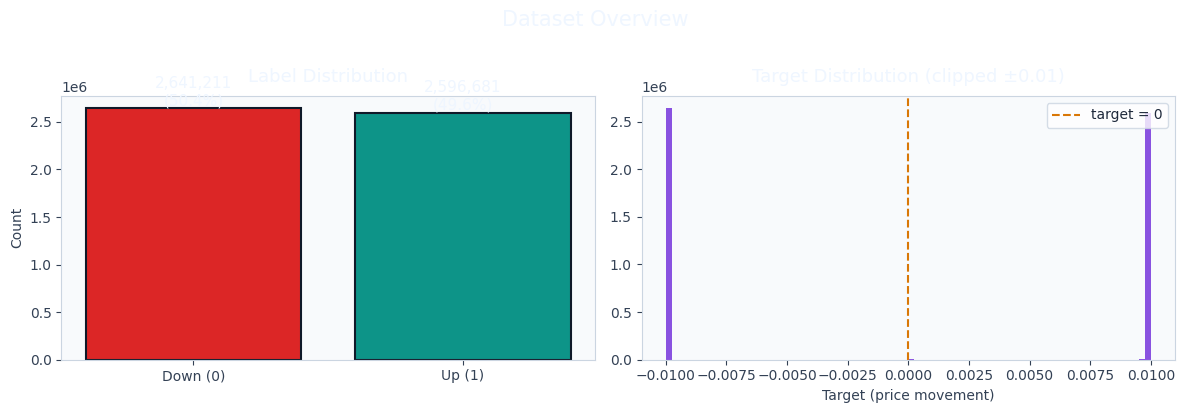


Class balance — Down: 50.4%  |  Up: 49.6%


In [39]:
# Label: 1 if WAP rises (target > 0), else 0
train["label"] = (train["target"] > 0).astype(int)

counts = train["label"].value_counts()
total  = len(train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["Down (0)", "Up (1)"], counts.values,
            color=[RED, TEAL], edgecolor="#0F1929", linewidth=1.5)
axes[0].set_title("Label Distribution", fontsize=13, color="#EFF6FF", pad=10)
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f"{v:,}\n({v/total:.1%})",
                 ha="center", va="bottom", fontsize=11, color="#EFF6FF")

# Target distribution
axes[1].hist(train["target"].clip(-0.01, 0.01), bins=80, color=PURPLE, alpha=0.8)
axes[1].axvline(0, color=AMBER, linewidth=1.5, linestyle="--", label="target = 0")
axes[1].set_title("Target Distribution (clipped ±0.01)", fontsize=13, color="#EFF6FF", pad=10)
axes[1].set_xlabel("Target (price movement)")
axes[1].legend()

fig.suptitle("Dataset Overview", fontsize=15, color="#EFF6FF", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nClass balance — Down: {counts[0]/total:.1%}  |  Up: {counts[1]/total:.1%}")


## 3. Preprocessing

In [40]:
# ── 3.1 Time bucketing ────────────────────────────────────────────────────
def group_time_intervals(df, interval_seconds):
    df = df.copy()
    df["time_group"] = (df["seconds_in_bucket"] // interval_seconds) * interval_seconds
    grouped = df.groupby(
        ["stock_id", "date_id", "time_group"], as_index=False
    ).agg({
        "seconds_in_bucket":    "last",
        "imbalance_size":       "mean",
        "imbalance_buy_sell_flag": "last",
        "reference_price":      "last",
        "matched_size":         "mean",
        "far_price":            "last",
        "near_price":           "last",
        "bid_price":            "last",
        "bid_size":             "mean",
        "ask_price":            "last",
        "ask_size":             "mean",
        "wap":                  "last",
        "target":               "last",
        "label":                "last",
    })
    return grouped

train = group_time_intervals(train, INTERVAL_SECONDS)
print(f"After bucketing: {train.shape}")


After bucketing: (5237892, 17)


In [41]:
# ── 3.2 Feature engineering ───────────────────────────────────────────────
# Static derived features
train["bid_ask_spread"]         = train["ask_price"] - train["bid_price"]
train["mid_price"]              = (train["ask_price"] + train["bid_price"]) / 2
train["imbalance_ratio"]        = train["imbalance_size"] / (train["matched_size"] + 1)
train["wap_reference_diff"]     = train["wap"] - train["reference_price"]
train["wap_mid_diff"]           = train["wap"] - train["mid_price"]
train["size_ratio"]             = train["bid_size"] / (train["ask_size"] + 1)
train["matched_imbalance_ratio"]= train["matched_size"] / (train["imbalance_size"] + 1)

# Sequence-aware features (rolling, lag — computed within stock+date groups)
def add_sequence_features(df):
    df  = df.sort_values(["stock_id", "date_id", "seconds_in_bucket"]).copy()
    grp = df.groupby(["stock_id", "date_id"])

    df["wap_lag1"]       = grp["wap"].shift(1)
    df["wap_return"]     = df["wap"] / (df["wap_lag1"].replace(0, np.nan) + 1e-8) - 1
    df["imbalance_roll3"]= grp["imbalance_ratio"].transform(
                               lambda x: x.rolling(3, min_periods=1).mean())
    df["spread_roll3"]   = grp["bid_ask_spread"].transform(
                               lambda x: x.rolling(3, min_periods=1).mean())
    df["wap_roll_std"]   = grp["wap"].transform(
                               lambda x: x.rolling(5, min_periods=1).std())
    return df.fillna(0)

train = add_sequence_features(train)
print("Feature engineering complete.")

# ── Feature list ──────────────────────────────────────────────────────────
FEATURES = [
    "seconds_in_bucket",
    "imbalance_size", "imbalance_buy_sell_flag",
    "reference_price", "matched_size",
    "far_price", "near_price",
    "bid_price", "bid_size", "ask_price", "ask_size", "wap",
    "bid_ask_spread", "mid_price",
    "imbalance_ratio", "wap_reference_diff", "wap_mid_diff",
    "size_ratio", "matched_imbalance_ratio",
    "wap_return", "imbalance_roll3", "spread_roll3", "wap_roll_std",
]
train[FEATURES] = train[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
print(f"Total features: {len(FEATURES)}")


Feature engineering complete.
Total features: 23


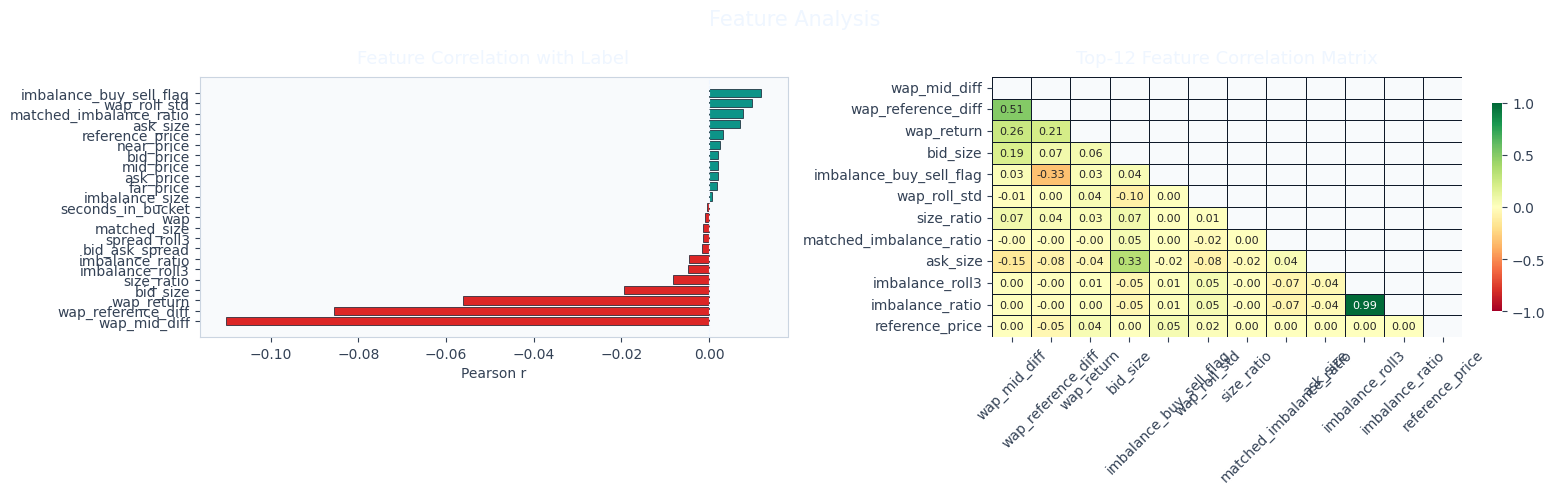

In [42]:
# ── 3.3 Feature correlation heatmap ──────────────────────────────────────
sample = train[FEATURES + ["label"]].sample(n=min(50_000, len(train)), random_state=SEED)
corr   = sample[FEATURES].corrwith(sample["label"]).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Correlation with label
colors_bar = [RED if v < 0 else TEAL for v in corr.values]
axes[0].barh(corr.index, corr.values, color=colors_bar, edgecolor="#0F1929", linewidth=0.5)
axes[0].axvline(0, color="#EFF6FF", linewidth=0.8, linestyle="--")
axes[0].set_title("Feature Correlation with Label", fontsize=13, color="#EFF6FF", pad=10)
axes[0].set_xlabel("Pearson r")

# Feature correlation matrix (top 12 by abs corr)
top12 = corr.abs().nlargest(12).index.tolist()
corr_matrix = sample[top12].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=axes[1],
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=0.4, linecolor="#0F1929",
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Top-12 Feature Correlation Matrix", fontsize=13, color="#EFF6FF", pad=10)
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("Feature Analysis", fontsize=15, color="#EFF6FF")
plt.tight_layout()
plt.show()


## 4. Train / Validation Split & DataLoader

In [43]:
# Sequence length derived from bucket interval
SEQ_MAP = {10: 55, 30: 19, 60: 10, 120: 5}
if INTERVAL_SECONDS not in SEQ_MAP:
    raise ValueError(f"INTERVAL_SECONDS must be one of {list(SEQ_MAP)}")
SEQ_LEN = SEQ_MAP[INTERVAL_SECONDS]
print(f"Sequence length: {SEQ_LEN} steps  ({SEQ_LEN * INTERVAL_SECONDS}s window)")

# Temporal split — earlier dates for training, later for validation
unique_dates = sorted(train["date_id"].unique())
split_idx    = int(0.8 * len(unique_dates))
train_dates  = unique_dates[:split_idx]
val_dates    = unique_dates[split_idx:]

train_df = train[train["date_id"].isin(train_dates)].copy()
val_df   = train[train["date_id"].isin(val_dates)].copy()

# Scale AFTER split — fit only on training data to prevent leakage
scaler = StandardScaler()
train_df[FEATURES] = scaler.fit_transform(train_df[FEATURES])
val_df[FEATURES]   = scaler.transform(val_df[FEATURES])

print(f"Train dates: {len(train_dates)}  |  Val dates: {len(val_dates)}")
print(f"Train rows:  {len(train_df):,}    |  Val rows:  {len(val_df):,}")


Sequence length: 55 steps  (550s window)
Train dates: 384  |  Val dates: 97
Train rows:  4,170,948    |  Val rows:  1,066,944


In [44]:
class StockDataset(Dataset):
    """
    Builds (sequence, label) pairs.
    Each sequence: SEQ_LEN time steps x len(FEATURES) features for one stock on one date.
    Label: direction at the final time step (1=Up, 0=Down).
    Only includes stock-date pairs with exactly SEQ_LEN steps (complete sequences).
    """
    def __init__(self, df):
        X_list, y_list = [], []
        for _, g in df.groupby(["stock_id", "date_id"]):
            g = g.sort_values("seconds_in_bucket")
            if len(g) == SEQ_LEN:
                X_list.append(g[FEATURES].values)
                y_list.append(g["label"].iloc[-1])
        self.X = torch.tensor(np.array(X_list), dtype=torch.float32)
        self.y = torch.tensor(np.array(y_list), dtype=torch.long)

    def __len__(self):  return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


train_dataset = StockDataset(train_df)
val_dataset   = StockDataset(val_df)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Tensor shapes — X: {train_dataset.X.shape}  y: {train_dataset.y.shape}")
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")


Tensor shapes — X: torch.Size([75834, 55, 23])  y: torch.Size([75834])
Train batches: 1185  |  Val batches: 304


## 5. Model Definition — GRU

In [45]:
class GRUModel(nn.Module):
    """
    Two-layer GRU for binary sequence classification.

    Architecture:
        Input  (batch, SEQ_LEN, n_features)
          → GRU x2  (hidden_size, num_layers, dropout)
          → last hidden state  (batch, hidden_size)
          → LayerNorm
          → Dropout
          → Linear(hidden_size, 2)
          → logits for [Down, Up]

    Why GRU over LSTM?
      - Fewer parameters (no cell state) → faster training on short sequences
      - Empirically comparable or better on financial time series of this length
    """
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 2),
        )

    def forward(self, x):
        _, hidden = self.gru(x)       # hidden: (num_layers, batch, hidden_size)
        last_hidden = hidden[-1]      # take last layer's hidden state
        return self.head(last_hidden)


model = GRUModel(
    input_size=len(FEATURES),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {train_params:,}")


GRUModel(
  (gru): GRU(23, 64, num_layers=2, batch_first=True, dropout=0.3)
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total parameters:     42,306
Trainable parameters: 42,306


## 6. Training

In [46]:
# ── Class-weighted loss (handles label imbalance) ─────────────────────────
label_counts  = train_df["label"].value_counts().sort_index()
class_weights = torch.tensor(
    [1.0 / label_counts[0], 1.0 / label_counts[1]], dtype=torch.float32
).to(device)
class_weights /= class_weights.sum()

loss_fn   = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    anneal_strategy="cos",
)

print(f"Class weights — Down: {class_weights[0]:.4f}  |  Up: {class_weights[1]:.4f}")


Class weights — Down: 0.4955  |  Up: 0.5045


In [47]:
# ── Training loop ─────────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "val_acc": [], "lr": []}

for epoch in range(1, EPOCHS + 1):
    # — Train —
    model.train()
    total_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss   = loss_fn(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

    # — Validate —
    model.eval()
    total_val_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = loss_fn(logits, y_batch)
            total_val_loss += loss.item()
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_train = total_train_loss / len(train_loader)
    avg_val   = total_val_loss   / len(val_loader)
    val_acc   = accuracy_score(all_labels, all_preds)
    cur_lr    = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_acc"].append(val_acc)
    history["lr"].append(cur_lr)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {avg_train:.4f} | "
          f"Val Loss: {avg_val:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"LR: {cur_lr:.2e}")

print("\nTraining complete.")


Epoch  1/10 | Train Loss: 0.6890 | Val Loss: 0.6566 | Val Acc: 0.6152 | LR: 2.80e-04
Epoch  2/10 | Train Loss: 0.6665 | Val Loss: 0.6528 | Val Acc: 0.6194 | LR: 7.60e-04
Epoch  3/10 | Train Loss: 0.6636 | Val Loss: 0.6517 | Val Acc: 0.6212 | LR: 1.00e-03
Epoch  4/10 | Train Loss: 0.6625 | Val Loss: 0.6519 | Val Acc: 0.6204 | LR: 9.50e-04
Epoch  5/10 | Train Loss: 0.6610 | Val Loss: 0.6509 | Val Acc: 0.6242 | LR: 8.12e-04
Epoch  6/10 | Train Loss: 0.6580 | Val Loss: 0.6479 | Val Acc: 0.6255 | LR: 6.11e-04
Epoch  7/10 | Train Loss: 0.6558 | Val Loss: 0.6465 | Val Acc: 0.6247 | LR: 3.89e-04
Epoch  8/10 | Train Loss: 0.6539 | Val Loss: 0.6452 | Val Acc: 0.6250 | LR: 1.88e-04
Epoch  9/10 | Train Loss: 0.6524 | Val Loss: 0.6450 | Val Acc: 0.6274 | LR: 4.94e-05
Epoch 10/10 | Train Loss: 0.6515 | Val Loss: 0.6451 | Val Acc: 0.6267 | LR: 4.04e-09

Training complete.


## 7. Training Curves

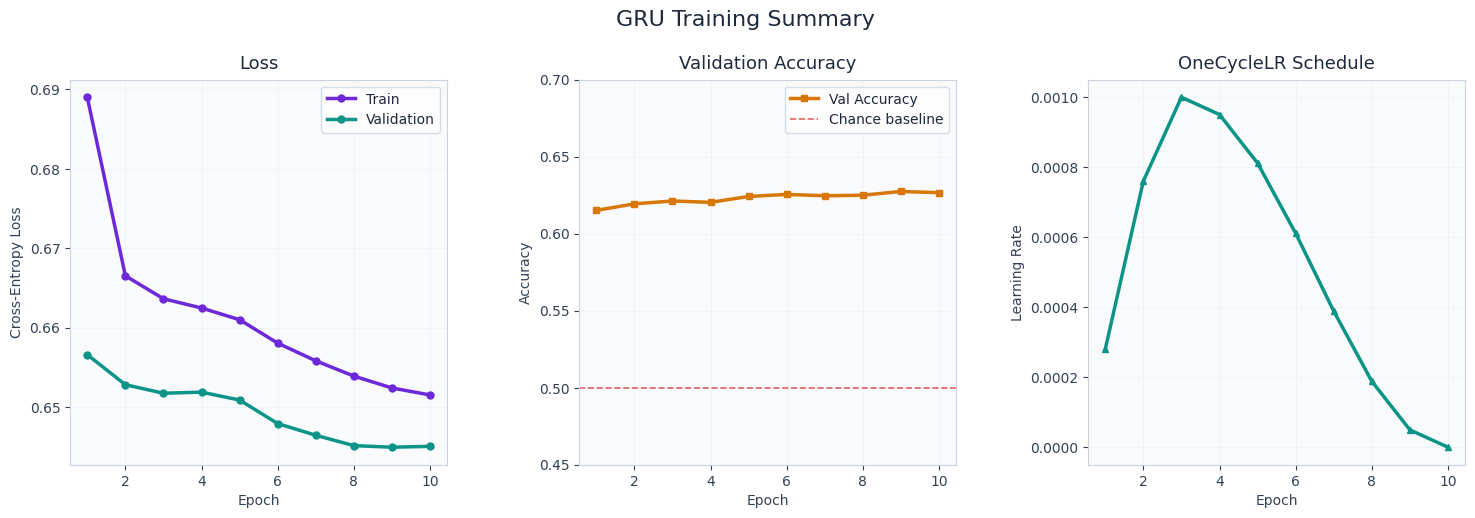

In [48]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

epochs_x = range(1, EPOCHS + 1)

# — Loss —
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_x, history["train_loss"], color=PURPLE, lw=2.5, marker="o",
         markersize=5, label="Train")
ax1.plot(epochs_x, history["val_loss"],   color=TEAL,   lw=2.5, marker="o",
         markersize=5, label="Validation")
ax1.set_title("Loss", fontsize=13, pad=8)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend(); ax1.grid(True, alpha=0.4)

# — Accuracy —
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_x, history["val_acc"], color=AMBER, lw=2.5, marker="s",
         markersize=5, label="Val Accuracy")
ax2.axhline(0.5, color=RED, lw=1.2, linestyle="--", alpha=0.7, label="Chance baseline")
ax2.set_ylim(0.45, 0.70)
ax2.set_title("Validation Accuracy", fontsize=13, pad=8)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend(); ax2.grid(True, alpha=0.4)

# — Learning Rate —
ax3 = fig.add_subplot(gs[2])
ax3.plot(epochs_x, history["lr"], color=TEAL, lw=2.5, marker="^", markersize=5)
ax3.set_title("OneCycleLR Schedule", fontsize=13, pad=8)
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Learning Rate")
ax3.grid(True, alpha=0.4)

fig.suptitle("GRU Training Summary", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 8. Final Evaluation

In [49]:
# ── Run final eval pass ───────────────────────────────────────────────────
model.eval()
final_preds, final_labels, final_probs = [], [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        probs   = torch.softmax(logits, dim=1)[:, 1]
        preds   = torch.argmax(logits, dim=1)
        final_preds.extend(preds.cpu().numpy())
        final_labels.extend(y_batch.numpy())
        final_probs.extend(probs.cpu().numpy())

acc     = accuracy_score(final_labels, final_preds)
auc     = roc_auc_score(final_labels, final_probs)
ll      = log_loss(final_labels, final_probs)

print(f"{'Metric':<22} {'Value':>10}")
print("-" * 34)
print(f"{'Validation Accuracy':<22} {acc:>10.4f}")
print(f"{'AUC-ROC':<22} {auc:>10.4f}")
print(f"{'Log Loss':<22} {ll:>10.4f}")
print()
print(classification_report(final_labels, final_preds,
                             target_names=["Down (0)", "Up (1)"]))


Metric                      Value
----------------------------------
Validation Accuracy        0.6267
AUC-ROC                    0.6744
Log Loss                   0.6446

              precision    recall  f1-score   support

    Down (0)       0.63      0.65      0.64      9847
      Up (1)       0.62      0.61      0.62      9551

    accuracy                           0.63     19398
   macro avg       0.63      0.63      0.63     19398
weighted avg       0.63      0.63      0.63     19398



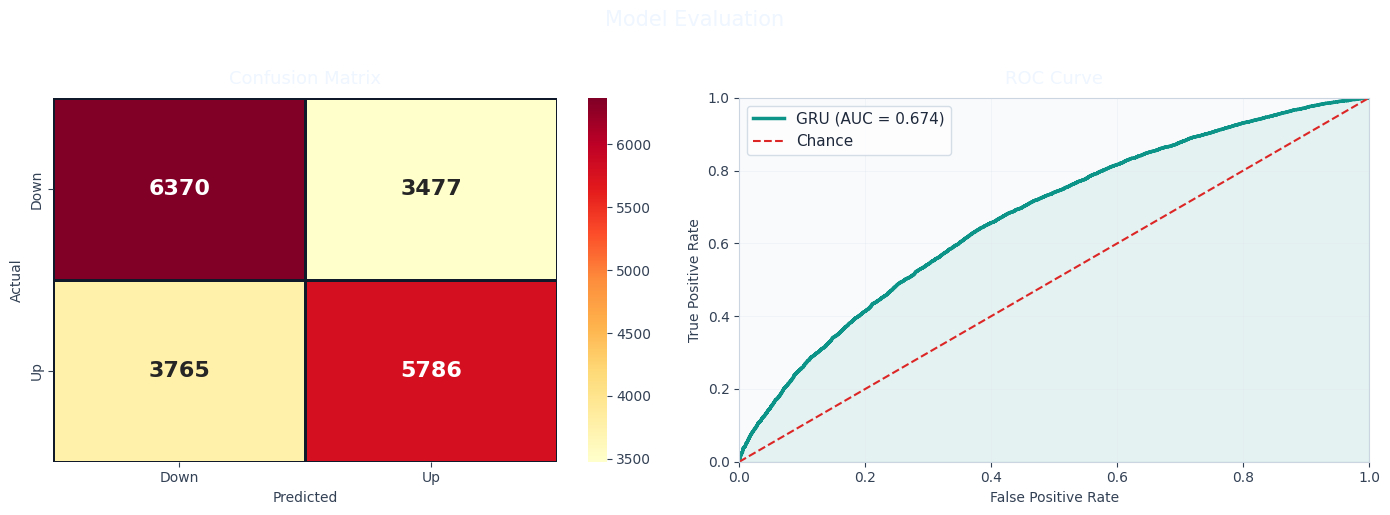

In [50]:
# ── Confusion matrix + ROC curve ──────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(final_labels, final_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=["Down", "Up"],
            yticklabels=["Down", "Up"],
            ax=axes[0],
            linewidths=1, linecolor="#0F1929",
            annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title("Confusion Matrix", fontsize=13, color="#EFF6FF", pad=10)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# ROC curve
fpr, tpr, _ = roc_curve(final_labels, final_probs)
axes[1].plot(fpr, tpr, color=TEAL,   lw=2.5, label=f"GRU (AUC = {auc:.3f})")
axes[1].plot([0,1],[0,1], color=RED, lw=1.5, linestyle="--", label="Chance")
axes[1].fill_between(fpr, tpr, alpha=0.08, color=TEAL)
axes[1].set_title("ROC Curve", fontsize=13, color="#EFF6FF", pad=10)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.4)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1])

fig.suptitle("Model Evaluation", fontsize=15, color="#EFF6FF", y=1.02)
plt.tight_layout()
plt.show()


## 9. Feature Importance (Input Gradient Proxy)

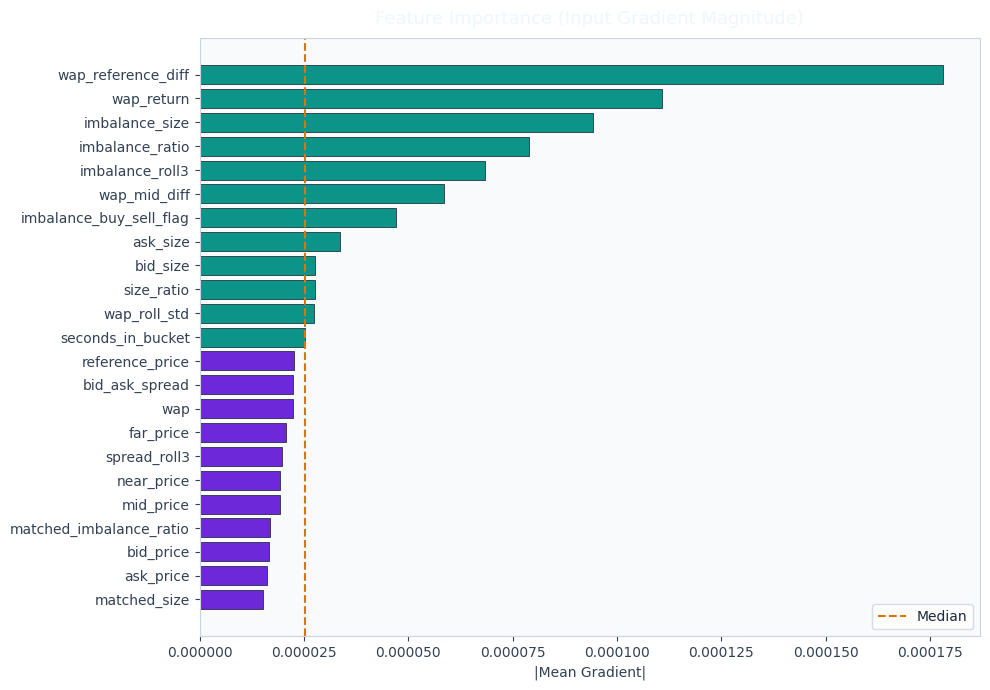

In [51]:
# ── Gradient-based sensitivity: |mean(dLoss/dInput)| per feature ──────────
# GRUs have no built-in importance score, so we measure how much each
# input feature influences the loss via backprop.

model.eval()
grad_accum = torch.zeros(len(FEATURES))
n_batches  = 0

for X_batch, y_batch in val_loader:
    X_batch = X_batch.to(device).requires_grad_(True)
    y_batch = y_batch.to(device)
    logits  = model(X_batch)
    loss    = loss_fn(logits, y_batch)
    loss.backward()
    # average absolute gradient across (batch, time) → shape (features,)
    grad_accum += X_batch.grad.abs().mean(dim=(0, 1)).detach().cpu()
    n_batches  += 1
    if n_batches >= 20:   # 20 batches is plenty for a stable estimate
        break

importance = (grad_accum / n_batches).numpy()
feat_df    = pd.DataFrame({"feature": FEATURES, "importance": importance})
feat_df    = feat_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = [TEAL if v >= feat_df["importance"].median() else PURPLE
             for v in feat_df["importance"]]
ax.barh(feat_df["feature"], feat_df["importance"],
        color=colors_fi, edgecolor="#0F1929", linewidth=0.5)
ax.axvline(feat_df["importance"].median(), color=AMBER, linewidth=1.5,
           linestyle="--", label="Median")
ax.set_title("Feature Importance (Input Gradient Magnitude)", fontsize=13,
             color="#EFF6FF", pad=10)
ax.set_xlabel("|Mean Gradient|")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Example Predictions

In [52]:
n_show = 15
results = pd.DataFrame({
    "Actual":    ["Up ↑" if l == 1 else "Down ↓" for l in final_labels[:n_show]],
    "Predicted": ["Up ↑" if p == 1 else "Down ↓" for p in final_preds[:n_show]],
    "P(Up)":     [f"{p:.3f}" for p in final_probs[:n_show]],
})
results["Correct"] = results["Actual"] == results["Predicted"]

print(results.to_string(index=True))
print(f"\nCorrect in first {n_show}: {results['Correct'].sum()}/{n_show}")


    Actual Predicted  P(Up)  Correct
0   Down ↓    Down ↓  0.483     True
1     Up ↑      Up ↑  0.528     True
2   Down ↓    Down ↓  0.440     True
3     Up ↑      Up ↑  0.651     True
4     Up ↑      Up ↑  0.553     True
5   Down ↓      Up ↑  0.574    False
6   Down ↓    Down ↓  0.485     True
7   Down ↓    Down ↓  0.428     True
8     Up ↑    Down ↓  0.488    False
9   Down ↓    Down ↓  0.373     True
10    Up ↑    Down ↓  0.391    False
11  Down ↓      Up ↑  0.587    False
12  Down ↓      Up ↑  0.530    False
13    Up ↑      Up ↑  0.611     True
14    Up ↑      Up ↑  0.568     True

Correct in first 15: 10/15


## 11. Save Model

In [53]:
torch.save({
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scaler":               scaler,
    "features":             FEATURES,
    "hyperparams": {
        "hidden_size": HIDDEN_SIZE,
        "num_layers":  NUM_LAYERS,
        "dropout":     DROPOUT,
        "seq_len":     SEQ_LEN,
        "interval_s":  INTERVAL_SECONDS,
    },
    "val_accuracy": acc,
    "val_auc":      auc,
}, "gru_nasdaq_model.pt")

print("Model saved to gru_nasdaq_model.pt")
print(f"Final Val Accuracy: {acc:.4f}  |  AUC-ROC: {auc:.4f}  |  Log Loss: {ll:.4f}")


Model saved to gru_nasdaq_model.pt
Final Val Accuracy: 0.6267  |  AUC-ROC: 0.6744  |  Log Loss: 0.6446
